# figure1_generation
This notebook generates figure 1 in Corrie et al. (in prep.). Contains code from the lead's author fmap module

In [35]:
import xarray as xa
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('../')
import fmap as fm
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.ticker import FuncFormatter as FF
import pandas as pd
import geopandas as gpd
import matplotlib.colors as mcolors

In [2]:
def isiterable(obj):
    '''
    Determines if passed object can be iterated.

    Parameters:
    - obj (object): Any object/datatype.

    Returns:
        bool: True or False if the obj is iterable.

    '''
    try:
        iter(obj)
        return True
    except TypeError:
        return False

def axes_labels(fig, ax, bounds, lonspacing, latspacing, label_size=10, style='all', rotation=None):
    '''
    Updates the axes x- and y- labels with coordinate information.

    Parameters:
    - fig (object): Overall figure object. Required parameter.
    - axs (object): 2d array of axs (see axes_2d and make_plots for the creation). Required parameter.
    - bounds (array_like): The west, east, north, and south coordinates of the map boundaries, respectively. Required parameter. Ideally this is the same as in the make_plots.
    - lonspacing (int): The spacing interval of longitude ticks labeled. Required parameter.
    - latspacing (int): The spacing interval of latitude ticks labeled. Required parameter.
    - label_size (int or float): Size of the labels. Default is 10.
    - style (str): Order in which labels are created. Default is 'all' (each subplot), but 'outer' is available (only left and bottom most subplots get lon and lat labels).
    - rotation (dict or None): How to rotate the labels. Default is None. If values are passed, the input must follow this format:
            rotation={'x': num_degx, 'y': num_degy}
            where num_deg{xy} is the number of degrees x or y to rotate. If only one of 'x' or 'y' are passed, the other is assumed to be 0.

    Returns:
        None
    '''

    def lon_formatter(x, pos):
        '''
        Formats the longitude to exclude negative signs and adds the appropriate letters.

        Parameters:
        - x: the longitude ticks
        - pos: position of each longitude tick.

        Notes:
        - No parameters are passed when this function is called.

        Returns:
            Formatted longitude ticks.
        '''
        if x % 180 == 0:
            return '{}°'.format(abs(x))
        elif x < 0:
            return '{}°W'.format(abs(x))
        elif x > 0:
            return '{}°E'.format(abs(x))

    def lat_formatter(y, pos):
        '''
        Formats the latitude to exclude negative signs and adds the appropriate letters.

        Parameters:
        - y: the latitude ticks
        - pos: position of each latitude tick.

        Notes:
        - No parameters are passed when this function is called.

        Returns:
            Formatted latitude ticks.
        '''
        if y < 0:
            return '{}°S'.format(abs(y))
        elif y > 0:
            return '{}°N'.format(abs(y))
        elif y == 0:
            return '{}°'.format(abs(y))

    # This block handles the subplots rotation based on the value passed.
    if rotation is None:
        rotx, roty = 0, 0
    elif isiterable(rotation):
        try:
            rotx = rotation['x']
        except KeyError:
            rotx = 0
        try:
            roty = rotation['y']
        except KeyError:
            roty = 0
    else:
        raise ValueError("'rotation' must be an x/y iterable, not {}".format(rotation))


    
    xticks = np.arange(bounds[0], bounds[1]+1, lonspacing)
    ax.set_xticks(xticks, crs=ccrs.PlateCarree())
    ax.set_xticklabels(xticks, fontsize=label_size, rotation=rotx)
    ax.xaxis.set_major_formatter(FF(lon_formatter))

    yticks = np.arange(bounds[3], bounds[2]+1, latspacing)
    ax.set_yticks(yticks, crs=ccrs.PlateCarree())
    ax.set_yticklabels(yticks, fontsize=label_size, rotation=roty)
    ax.yaxis.set_major_formatter(FF(lat_formatter))

Text(-139, 47.40000000000025, 'Washington (WA)')

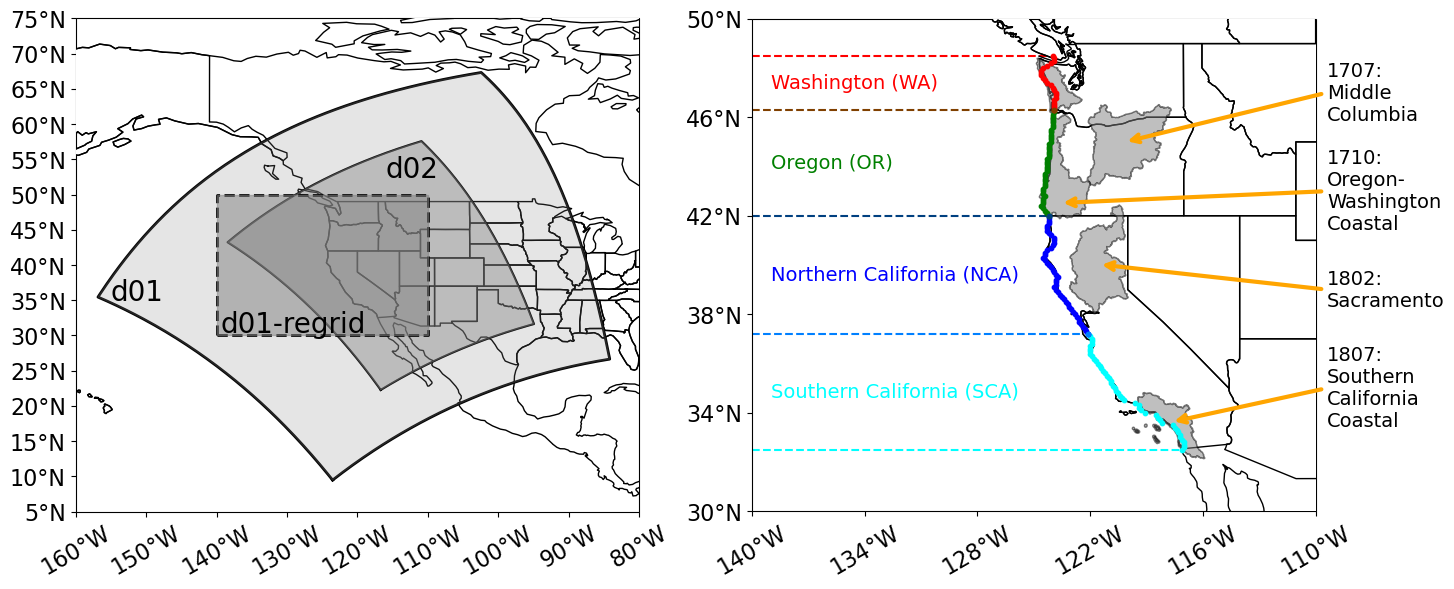

In [54]:
f1, a1 = plt.subplots(1, 2, subplot_kw=dict(projection=ccrs.PlateCarree()), figsize=(16,11))

a1 = fm.axes_2d(a1, 1, 2)

# Set the bounds for each subplot differently
a1[0,0].set_extent([-160, -80, 5, 70])
a1[0,1].set_extent([-140, -110, 30, 45])

# Adds State/Country/Land borders
for i in range(2):
    a1[0,i].add_feature(cfeature.STATES, edgecolor="black", zorder=100)
    a1[0,i].add_feature(cfeature.BORDERS, edgecolor="black", zorder=99)
    a1[0,i].add_feature(cfeature.LAND, edgecolor="black", zorder=99, facecolor='white')

# Sets the subpanel bounds
axes_labels(f1, a1[0,0], [-160, -80, 75, 5], 10, 5, label_size=16, rotation={'x': 30})
axes_labels(f1, a1[0,1], [-140, -110, 50, 30], 6, 4, label_size=16, rotation={'x': 30})

##### LEFT SUBPANEL #########

# Plots the WUS-D3 d01 bounds (45 km)
d01 = xa.open_dataset('/glade/campaign/uwyo/wyom0169/wus-d3/postprocess/meta/meta_new/wrfinput_d01')
ds_lon_d01 = d01.variables['XLONG'][:].squeeze()
ds_lat_d01 = d01.variables['XLAT'][:].squeeze()
boundary_lon_d01 = np.concatenate([
    ds_lon_d01[0, :],        # bottom row
    ds_lon_d01[1:, -1],      # right column
    ds_lon_d01[-1, -2::-1],  # top row (reversed)
    ds_lon_d01[-2::-1, 0],   # left column (reversed)
])
boundary_lat_d01 = np.concatenate([
    ds_lat_d01[0, :],        # bottom row
    ds_lat_d01[1:, -1],      # right column
    ds_lat_d01[-1, -2::-1],  # top row (reversed)
    ds_lat_d01[-2::-1, 0],   # left column (reversed)
])

a1[0,0].plot(boundary_lon_d01, boundary_lat_d01, color='k', linewidth=2, zorder=101)
a1[0,0].fill(boundary_lon_d01, boundary_lat_d01, color='gray', alpha=0.2, zorder=101)

# Plots the WUS-D3 d02 bounds (9 km)
d02 = xa.open_dataset('/glade/campaign/uwyo/wyom0169/wus-d3/postprocess/meta/meta_new/wrfinput_d02')
ds_lon_d02 = d02.variables['XLONG'][:].squeeze()
ds_lat_d02 = d02.variables['XLAT'][:].squeeze()
boundary_lon_d02 = np.concatenate([
    ds_lon_d02[0, :],        # bottom row
    ds_lon_d02[1:, -1],      # right column
    ds_lon_d02[-1, -2::-1],  # top row (reversed)
    ds_lon_d02[-2::-1, 0],   # left column (reversed)
])
boundary_lat_d02 = np.concatenate([
    ds_lat_d02[0, :],        # bottom row
    ds_lat_d02[1:, -1],      # right column
    ds_lat_d02[-1, -2::-1],  # top row (reversed)
    ds_lat_d02[-2::-1, 0],   # left column (reversed)
])

a1[0,0].plot(boundary_lon_d02, boundary_lat_d02, color='k', linewidth=1.5, zorder=101)
a1[0,0].fill(boundary_lon_d02, boundary_lat_d02, color='gray', alpha=0.4, zorder=101)

# Plots the regridded WUS-D3 d01 bounds (0.1° deg x 0.1° lon)
boundary_lon_regrid = np.concatenate([
    np.arange(-140, -109.9, 0.1),
    np.repeat(-110, int((50-30)/0.1)),
    np.arange(-110, -140.1, -0.1),
    np.repeat(-140, int((50-30)/0.1))
])

boundary_lat_regrid = np.concatenate([
    np.repeat(30, int((-110+140)/0.1)),
    np.arange(30, 50.1, 0.1),
    np.repeat(50, int((-110+140)/0.1)),
    np.arange(50, 29.9, -0.1)
])

a1[0,0].plot(boundary_lon_regrid, boundary_lat_regrid, color='k', linewidth=2, linestyle='dashed', zorder=101)
a1[0,0].fill(boundary_lon_regrid, boundary_lat_regrid, color='gray', alpha=0.5, zorder=101)

# Add text labels
a1[0,0].text(-155, 35, 'd01', fontsize=20, transform=ccrs.PlateCarree(), zorder=102)
a1[0,0].text(-116, 52.5, 'd02', fontsize=20, transform=ccrs.PlateCarree(), zorder=102)
a1[0,0].text(-139.5, 30.5, 'd01-regrid', fontsize=20, transform=ccrs.PlateCarree(), zorder=102)

##### RIGHT SUBPANEL #########

# Read in watershed shapefiles
wus_db = gpd.read_file('../watersheds_WUS.geojson', driver='GeoJSON')
wus_db_focus = wus_db[wus_db['huc4'].isin(['1707', '1710', '1802', '1807'])] # Subselected the four watersheds shown in this study
wus_db_focus['geometry'].plot(edgecolor='black', facecolor='gray', alpha=0.5, ax=a1[0,1], zorder=103)

wshed_yorder = ['1707', '1710', '1802', '1807']

for idx, watershed in wus_db_focus.iterrows():

    # 1710s centroid is in a weird spot so we adjust the target position slightly.
    xypos = (watershed.geometry.centroid.x, watershed.geometry.centroid.y-2) if watershed.huc4=='1710' else \
    (watershed.geometry.centroid.x, watershed.geometry.centroid.y)

    # Define arrow props
    aprops = dict(facecolor='orange', edgecolor='orange', arrowstyle='->', relpos=(0.0, 0.5), linewidth= 3)

    # Define namestring
    namesplit = "\n".join(watershed["name"].replace('-','-\n').split(" "))
    # Annotate each watershed
    a1[0, 1].annotate(f'{watershed.huc4}:\n{namesplit}',
                      xy=xypos,
                      xytext=(1.02, 0.85-0.20*wshed_yorder.index(watershed.huc4)),
                      xycoords=ccrs.PlateCarree()._as_mpl_transform(a1[0, 1]),
                      textcoords='axes fraction',
                      ha='left', va='center',
                      arrowprops=aprops,
                      fontsize=14,
                      zorder=104
                     )

# Get the regridded landmask, pull the coastal points, get coordinates
land = xa.open_dataset('/glade/derecho/scratch/tcorrie/regrids/landmask_regridded.nc')
coast = xa.where(land['LANDMASK'] >= 0.5, 1, 0).idxmax(dim='lon')
def get_coast_coords(min_lat, max_lat):
        coast_subs = coast.sel(lat=slice(min_lat, max_lat))
        coast_lats = coast_subs.lat.data
        coast_lons = coast_subs.data
        return(coast_lons, coast_lats)

coast_lons_wus, coast_lats_wus = get_coast_coords(32.5,48.51)
coast_lons_sca, coast_lats_sca = get_coast_coords(32.5,37.21)
coast_lons_nca, coast_lats_nca = get_coast_coords(37.2,42.01)
coast_lons_or, coast_lats_or = get_coast_coords(42.0,46.31)
coast_lons_wa, coast_lats_wa = get_coast_coords(46.3,48.51)

# Plot coastal points, color coding by color
a1[0,1].scatter(coast_lons_sca, coast_lats_sca, color='cyan', s=10, zorder=105)
a1[0,1].scatter(coast_lons_nca, coast_lats_nca, color='blue', s=10, zorder=105)
a1[0,1].scatter(coast_lons_or, coast_lats_or, color='green', s=10, zorder=105)
a1[0,1].scatter(coast_lons_wa, coast_lats_wa, color='red', s=10, zorder=105)

# Border points are color blended
def color_blend(c1, c2):
    return 0.5*np.array(mcolors.to_rgb(c1))+0.5*np.array(mcolors.to_rgb(c2))

# Plot the boundary coastal points
a1[0,1].scatter(coast_lons_sca[-1], coast_lats_sca[-1], color=color_blend('cyan', 'blue'), s=10, zorder=106)
a1[0,1].scatter(coast_lons_nca[-1], coast_lats_nca[-1], color=color_blend('blue', 'green'), s=10, zorder=106)
a1[0,1].scatter(coast_lons_or[-1], coast_lats_or[-1], color=color_blend('green', 'red'), s=10, zorder=106)

# Plot the dotted boundary lines
a1[0,1].hlines(coast_lats_sca[0], -140, coast_lons_sca[0], color=color_blend('cyan', 'cyan'), linestyle='dashed', transform=ccrs.PlateCarree())
a1[0,1].hlines(coast_lats_sca[-1], -140, coast_lons_sca[-1], color=color_blend('cyan', 'blue'), linestyle='dashed', transform=ccrs.PlateCarree())
a1[0,1].hlines(coast_lats_nca[-1], -140, coast_lons_nca[-1], color=color_blend('blue', 'green'), linestyle='dashed', transform=ccrs.PlateCarree())
a1[0,1].hlines(coast_lats_or[-1], -140, coast_lons_or[-1], color=color_blend('green', 'red'), linestyle='dashed', transform=ccrs.PlateCarree())
a1[0,1].hlines(coast_lats_wa[-1], -140, coast_lons_wa[-1], color=color_blend('red', 'red'), linestyle='dashed', transform=ccrs.PlateCarree())

# Add text to show landfall regions
a1[0,1].text(-139, np.mean(coast_lats_sca), 'Southern California (SCA)', fontsize=14, color='cyan', va='center')
a1[0,1].text(-139, np.mean(coast_lats_nca), 'Northern California (NCA)', fontsize=14, color='blue', va='center')
a1[0,1].text(-139, np.mean(coast_lats_or), 'Oregon (OR)', fontsize=14, color='green', va='center')
a1[0,1].text(-139, np.mean(coast_lats_wa), 'Washington (WA)', fontsize=14, color='red', va='center')


In [55]:
fm.save(f1, '/glade/work/tcorrie/ARdata/Figures/JoC/boundaries_all.png')